Loaded 33 calibration spectra with 7468 features each.
Loaded 4 solvent spectra.

Generating synthetic calibration data for YH_2025_007_DEE...
Generating synthetic calibration data for YH_2025_007_DMSO...
Generating synthetic calibration data for YH_2025_007_IPA...
Generating synthetic calibration data for YH_2025_007_Water...
Calibration dataset expanded to 561 samples (≈ 4× original with solvent contamination).

Testing 12 files...

Prediction for YH_2026_019_DEE_A.CSV: y = 0.6007, MAE = 0.199267
Prediction for YH_2026_019_DEE_B.CSV: y = 0.4290, MAE = 0.371049
Prediction for YH_2026_019_DEE_C.CSV: y = 0.4364, MAE = 0.363642
Prediction for YH_2026_019_DMSO_A.CSV: y = 0.2181, MAE = 0.581923
Prediction for YH_2026_019_DMSO_B.CSV: y = 0.4192, MAE = 0.380756
Prediction for YH_2026_019_DMSO_C.CSV: y = 0.3636, MAE = 0.436364
Prediction for YH_2026_019_IPA_A.CSV: y = 0.4439, MAE = 0.356068
Prediction for YH_2026_019_IPA_B.CSV: y = 0.2557, MAE = 0.544295
Prediction for YH_2026_019_IPA_C.CSV: 

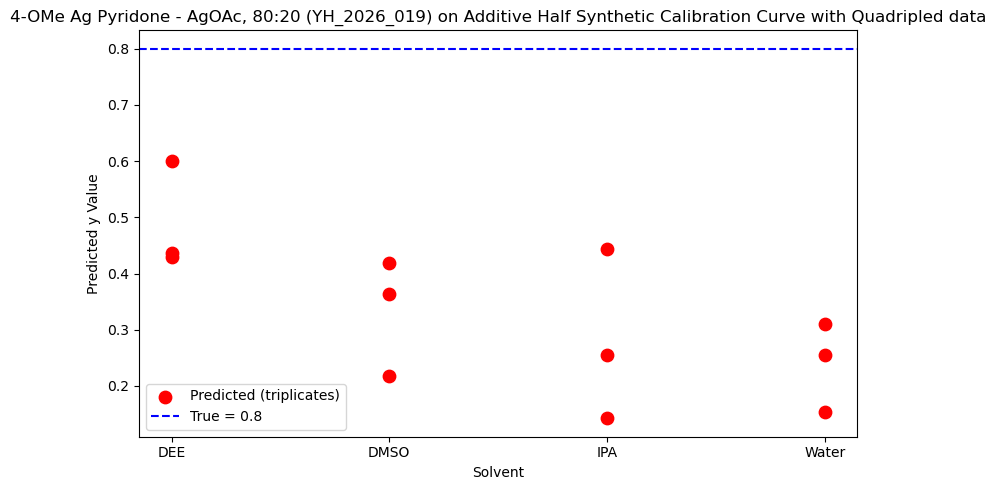


Triplicate-level results saved to YH_2025_009_grouped_triplicates_results.csv


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error

root_calib = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_005/' 
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_019/'

calib_files = sorted([f for f in os.listdir(root_calib) if f.lower().endswith('.csv')])[:33]
y_values = [1, 1, 1, 0.9, 0.9, 0.9, 0.8, 0.8, 0.8,
           0.7, 0.7, 0.7, 0.6, 0.6, 0.6, 0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 
            0.3, 0.3, 0.3, 0.2, 0.2, 0.2, 0.1, 0.1, 0.1, 0,0,0]

solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

alphas = np.arange(0.1, 0.5, 0.1)
n_components = 5
true_y = 0.8

def load_spectrum(file_path):
    """Load 2nd column of CSV as spectrum."""
    data = pd.read_csv(file_path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def synthesize_spectrum(calib, solvent, alpha):
    """Add solvent contamination (100% + α×solvent)."""
    return calib + alpha * solvent

calib_rows = []
for file, y_val in zip(calib_files, y_values):
    spectrum = load_spectrum(os.path.join(root_calib, file))
    row = np.insert(spectrum, 0, y_val)
    calib_rows.append(row)

min_len = min(len(r) for r in calib_rows)
calib_rows = [r[:min_len] for r in calib_rows]
columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
calib_df = pd.DataFrame(calib_rows, columns=columns)

y_calib = calib_df['y'].values
X_calib = calib_df.drop('y', axis=1).values
n_samples, n_features = X_calib.shape
print(f"Loaded {n_samples} calibration spectra with {n_features} features each.")

solvents = {}
for file in solvent_files:
    spec = load_spectrum(os.path.join(solvent_dir, file))
    if len(spec) != n_features:
        spec = np.interp(np.linspace(0, 1, n_features),
                         np.linspace(0, 1, len(spec)), spec)
        print(f"Interpolated {file} to {n_features} points")
    solvents[file.split('.')[0]] = spec

print(f"Loaded {len(solvents)} solvent spectra.\n")

X_augmented = [X_calib]
y_augmented = [y_calib]

for solvent_name, solvent_spec in solvents.items():
    print(f"Generating synthetic calibration data for {solvent_name}...")
    for alpha in alphas:
        X_synth = np.array([synthesize_spectrum(x_row, solvent_spec, alpha) for x_row in X_calib])
        X_augmented.append(X_synth)
        y_augmented.append(y_calib)

X_calib_all = np.vstack(X_augmented)
y_calib_all = np.concatenate(y_augmented)
print(f"Calibration dataset expanded to {len(X_calib_all)} samples (≈ 4× original with solvent contamination).\n")

pls = PLSRegression(n_components=n_components)
pls.fit(X_calib_all, y_calib_all)

test_files = sorted([f for f in os.listdir(test_dir) if f.lower().endswith('.csv')])
print(f"Testing {len(test_files)} files...\n")

predictions = []
maes = []

for test_file in test_files:
    test_spec = load_spectrum(os.path.join(test_dir, test_file))[:n_features]
    y_pred = float(pls.predict(test_spec.reshape(1, -1))[0])
    mae = mean_absolute_error([true_y], [y_pred])
    
    predictions.append((test_file, y_pred))
    maes.append(mae)
    
    print(f"Prediction for {test_file}: y = {y_pred:.4f}, MAE = {mae:.6f}")

print(f"\nAverage MAE across all test files: {np.mean(maes):.6f}")

solvent_labels = ['DEE', 'DMSO', 'IPA', 'Water']
x_positions = np.repeat(np.arange(len(solvent_labels)), 3)
y_values_plot = [p[1] for p in predictions]

plt.figure(figsize=(8, 5))
plt.scatter(x_positions, y_values_plot, color='red', s=80, label='Predicted (triplicates)')
plt.axhline(y=true_y, color='blue', linestyle='--', label=f'True = {true_y}')
plt.xticks(range(len(solvent_labels)), solvent_labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y Value')
plt.title('4-OMe Ag Pyridone - AgOAc, 80:20 (YH_2026_019) on Additive Half Synthetic Calibration Curve with Quadripled data')
plt.legend()
plt.tight_layout()
plt.show()

results_df = pd.DataFrame({
    'Test_File': [p[0] for p in predictions],
    'Predicted_y': [p[1] for p in predictions],
    'MAE': maes
})
results_df.to_csv('YH_2025_009_grouped_triplicates_results.csv', index=False)
print("\nTriplicate-level results saved to YH_2025_009_grouped_triplicates_results.csv")

Found 12 test files
YH_2026_019_DEE_A.CSV: y=0.6630, MAE=0.137027
YH_2026_019_DEE_B.CSV: y=0.4352, MAE=0.364778
YH_2026_019_DEE_C.CSV: y=0.4775, MAE=0.322540
YH_2026_019_DMSO_A.CSV: y=0.3298, MAE=0.470212
YH_2026_019_DMSO_B.CSV: y=0.5438, MAE=0.256176
YH_2026_019_DMSO_C.CSV: y=0.4597, MAE=0.340268
YH_2026_019_IPA_A.CSV: y=0.5157, MAE=0.284305
YH_2026_019_IPA_B.CSV: y=0.3175, MAE=0.482472
YH_2026_019_IPA_C.CSV: y=0.1866, MAE=0.613419
YH_2026_019_Water_A.CSV: y=0.4393, MAE=0.360709
YH_2026_019_Water_B.CSV: y=0.1856, MAE=0.614408
YH_2026_019_Water_C.CSV: y=0.3488, MAE=0.451218

Average MAE: 0.391461


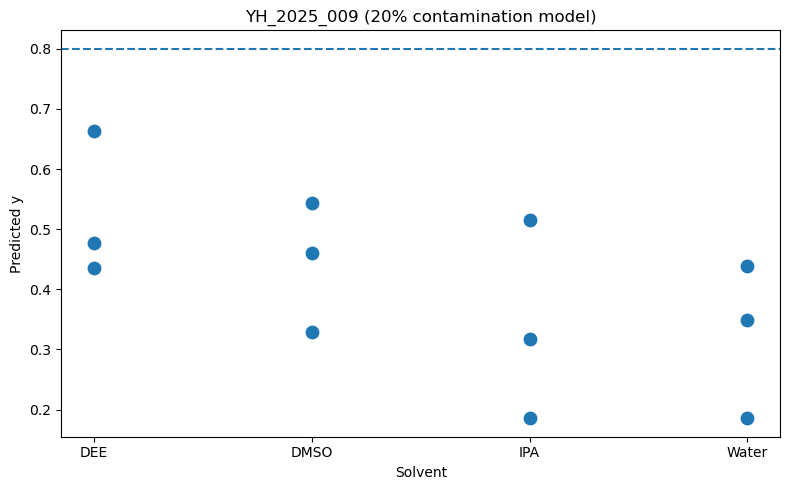

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

root_calib = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_005/' 
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_019/'

#SETTINGS
n_components = 5
true_y = 0.8
alphas = np.arange(0.05, 0.25, 0.05)  # up to 20%

calib_files = sorted([f for f in os.listdir(root_calib) if f.lower().endswith('.csv')])[:33]

y_values = [1, 1, 1, 0.9, 0.9, 0.9, 0.8, 0.8, 0.8,
           0.7, 0.7, 0.7, 0.6, 0.6, 0.6, 0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 
            0.3, 0.3, 0.3, 0.2, 0.2, 0.2, 0.1, 0.1, 0.1, 0,0,0]

solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

#FUNCTIONS
def load_spectrum(file_path):
    data = pd.read_csv(file_path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def synthesize_spectrum(calib, solvent, alpha):
    contaminated = calib + alpha * solvent
    return contaminated / (1 + alpha)

#LOAD CALIBRATION
calib_rows = []
for file, y_val in zip(calib_files, y_values):
    spectrum = load_spectrum(os.path.join(root_calib, file))
    row = np.insert(spectrum, 0, y_val)
    calib_rows.append(row)

min_len = min(len(r) for r in calib_rows)
calib_rows = [r[:min_len] for r in calib_rows]

columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
calib_df = pd.DataFrame(calib_rows, columns=columns)

y_calib = calib_df['y'].values
X_calib = calib_df.drop('y', axis=1).values

solvents = {}
for file in solvent_files:
    spec = load_spectrum(os.path.join(solvent_dir, file))
    if len(spec) != X_calib.shape[1]:
        spec = np.interp(np.linspace(0,1,X_calib.shape[1]),
                         np.linspace(0,1,len(spec)), spec)
    solvents[file.split('.')[0]] = spec

# AUGMENTATION
X_augmented = [X_calib]
y_augmented = [y_calib]

for solvent_name, solvent_spec in solvents.items():
    for alpha in alphas:
        X_synth = np.array([
            synthesize_spectrum(x, solvent_spec, alpha)
            for x in X_calib
        ])
        X_augmented.append(X_synth)
        y_augmented.append(y_calib)

X_all = np.vstack(X_augmented)
y_all = np.concatenate(y_augmented)

scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)

#MODEL
pls = PLSRegression(n_components=n_components)
pls.fit(X_all_scaled, y_all)

# TEst
test_files = sorted([
    f for f in os.listdir(test_dir)
    if f.lower().endswith('.csv')
])

print(f"Found {len(test_files)} test files")

if len(test_files) == 0:
    raise ValueError(f"No CSV test files found in: {test_dir}")

predictions = []
maes = []

for file in test_files:
    spec = load_spectrum(os.path.join(test_dir, file))[:X_calib.shape[1]]
    spec_scaled = scaler.transform(spec.reshape(1, -1))
    
    y_pred = float(pls.predict(spec_scaled)[0])
    mae = mean_absolute_error([true_y], [y_pred])
    
    predictions.append((file, y_pred))
    maes.append(mae)
    
    print(f"{file}: y={y_pred:.4f}, MAE={mae:.6f}")

if len(maes) > 0:
    print(f"\nAverage MAE: {np.mean(maes):.6f}")
else:
    print("\nNo predictions made — check test data.")

solvent_labels = ['DEE','DMSO','IPA','Water']
x_positions = []
y_plot = []

for file, y_pred in predictions:
    for i, solvent in enumerate(solvent_labels):
        if solvent in file:
            x_positions.append(i)
            y_plot.append(y_pred)
            break

plt.figure(figsize=(8,5))
plt.scatter(x_positions, y_plot, s=80)
plt.axhline(y=true_y, linestyle='--')

plt.xticks(range(len(solvent_labels)), solvent_labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y')
plt.title('YH_2025_009 (20% contamination model)')
plt.tight_layout()
plt.show()